# Cell 1 _ Importing lilbraries

In [5]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, Embedding, Dropout, add)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle
import time

print("Tensorflow version", tf.__version__)
print("GPU available :", tf.config.list_physical_devices('GPU'))

Tensorflow version 2.20.0
GPU available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Cell 2 _ Verifying the dataset

In [6]:
print("Top level:", os.listdir('/kaggle/input/datasets/adityajn105/flickr8k'))

Top level: ['captions.txt', 'Images']


# Cell 3 _ Loading & Exploring the captions file

In [7]:
captions_path = '/kaggle/input/datasets/adityajn105/flickr8k/captions.txt'
images_path  = '/kaggle/input/datasets/adityajn105/flickr8k/Images'

with open(captions_path, 'r') as f:
    content = f.read()

print("First 500 characters:")
print(content[:500])
print("\nTotal lines :", len(content.strip().split('\n')))

First 500 characters:
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1001773457_577c3

Total lines : 40456


# Parsing captions into a dict

In [8]:
def load_captions(filepath):
    captions = {}

    with open(filepath, 'r') as f:
        next(f)  # skip header row
        for line in f:
            line = line.strip()
            if not line:
                continue

            # split only on the first comma, captions themselves can contain commas
            parts = line.split(',', 1)
            if len(parts) != 2:
                continue

            image_id, caption = parts

            # clean up the caption
            caption = caption.lower()
            caption = ''.join(c for c in caption if c.isalpha() or c == ' ')
            caption = 'startseq ' + caption.strip() + ' endseq' 

            if image_id not in captions:
                captions[image_id] = []
            captions[image_id].append(caption)

    return captions

captions = load_captions(captions_path)

print(f"Total unique images: {len(captions)}")
print(f"nSample captions for one image:")
sample_key = list(captions.keys())[0]
print(f"Image: {sample_key}")
for cap in captions[sample_key]:
    print(f" {cap}")

Total unique images: 8091
nSample captions for one image:
Image: 1000268201_693b08cb0e.jpg
 startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
 startseq a girl going into a wooden building endseq
 startseq a little girl climbing into a wooden playhouse endseq
 startseq a little girl climbing the stairs to her playhouse endseq
 startseq a little girl in a pink dress going into a wooden cabin endseq


# Cell 5 _ Extracting image features using InceptionV3

In [9]:
# Load InceptionV3 without the classification top
encoder = InceptionV3(weights='imagenet', include_top=False, pooling='avg')

print(f"InceptionV3 feature vector size: {encoder.output_shape}")

def extract_features(image_path, model, img_size=299):
    img = load_img(image_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = model.predict(img_array, verbose=0)
    return features[0]

# Extract features for ALL 8,091 images — this takes a while, progress every 500
features = {}
image_ids = list(captions.keys())
start_time = time.time()

for i, image_id in enumerate(image_ids):
    img_path = os.path.join(images_path, image_id)
    if os.path.exists(img_path):
        features[image_id] = extract_features(img_path, encoder)
    
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {i+1}/{len(image_ids)} images — {elapsed:.0f}s elapsed")

print(f"\nDone! Extracted features for {len(features)} images")
print(f"Feature vector shape: {features[list(features.keys())[0]].shape}")

# Save to disk — we never want to run this cell twice
with open('/kaggle/working/image_features.pkl', 'wb') as f:
    pickle.dump(features, f)
print("Features saved to disk!")

I0000 00:00:1782979570.824722      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782979570.830774      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
InceptionV3 feature vector size: (None, 2048)


I0000 00:00:1782979587.210962     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processed 500/8091 images — 64s elapsed
Processed 1000/8091 images — 119s elapsed
Processed 1500/8091 images — 173s elapsed
Processed 2000/8091 images — 228s elapsed
Processed 2500/8091 images — 283s elapsed
Processed 3000/8091 images — 338s elapsed
Processed 3500/8091 images — 394s elapsed
Processed 4000/8091 images — 449s elapsed
Processed 4500/8091 images — 505s elapsed
Processed 5000/8091 images — 561s elapsed
Processed 5500/8091 images — 618s elapsed
Processed 6000/8091 images — 674s elapsed
Processed 6500/8091 images — 730s elapsed
Processed 7000/8091 images — 785s elapsed
Processed 7500/8091 images — 841s elapsed
Processed 8000/8091 images — 898s elapsed

Done! Extracted features for 8091 images
Feature vector shape: (2048,)
Features saved to disk!


# Cell 6 _ Building the vocabulary & tokenizer 

In [10]:
# Collect all caption text into one flat list
all_captions = []
for caps in captions.values():
    all_captions.extend(caps)

print(f"Total captions: {len(all_captions)}")

# Build the tokenizer on all captions
tokenizer = Tokenizer(oov_token='<unk>')
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token (index 0)
print(f"Vocabulary size: {vocab_size}")

# Find the longest caption — needed for padding
max_caption_length = max(len(cap.split()) for cap in all_captions)
print(f"Longest caption: {max_caption_length} words")

# Show a few word-to-index mappings
print("\nSample vocabulary entries:")
sample_words = ['startseq', 'endseq', 'dog', 'running', 'beach', '<unk>']
for word in sample_words:
    if word in tokenizer.word_index:
        print(f"  '{word}' → index {tokenizer.word_index[word]}")

# Save tokenizer to disk alongside features
with open('/kaggle/working/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("\nTokenizer saved!")

Total captions: 40455
Vocabulary size: 8782
Longest caption: 37 words

Sample vocabulary entries:
  'startseq' → index 3
  'endseq' → index 4
  'dog' → index 10
  'running' → index 33
  'beach' → index 67
  '<unk>' → index 1

Tokenizer saved!


# Cell 7 _ Creating the train/test split

In [11]:
import random

random.seed(42)
image_ids = list(captions.keys())
random.shuffle(image_ids)

split = int(0.9 * len(image_ids))
train_ids = image_ids[:split]
test_ids = image_ids[split:]

print(f"Train images: {len(train_ids)}")
print(f"test images: {len(test_ids)}")


Train images: 7281
test images: 810


# Cell 8 _ Building the data generator

In [31]:
def data_generator(image_ids, captions, features, tokenizer,
                   max_length, vocab_size, batch_size=64):
    while True:
        X1, X2, y = [], [], []

        for image_id in image_ids:
            if image_id not in features:
                continue

            for caption in captions[image_id]:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq = pad_sequences([seq[:i]], maxlen=max_length)[0]
                    out_word = tf.keras.utils.to_categorical(
                                   [seq[i]], num_classes=vocab_size)[0]

                    X1.append(features[image_id])
                    X2.append(in_seq)
                    y.append(out_word)

                    if len(X1) == batch_size:
                        yield (
                            np.array(X1, dtype=np.float32),
                            np.array(X2, dtype=np.int32),
                            np.array(y, dtype=np.float32)
                        )
                        X1, X2, y = [], [], []

print("Generator function defined")

Generator function defined


# Cell 9 _ Building the model architecture

In [32]:
# Image feature input
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Caption sequence input
inputs2 = Input(shape=(max_caption_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256, use_cudnn=False)(se2)

# Merge both inputs and generate output
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy'
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 37, 256)   │  2,248,192 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 2048)      │          0 │ input_layer_13[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 37, 256)   │          0 │ embedding_5[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 37)        │          0 │ input_layer_14[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256)       │    524,544 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 256)       │    525,312 │ dropout_12[0][0], │
│                     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ dense_14[0][0],   │
│                     │                   │            │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │     65,792 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8782)      │  2,256,974 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,620,814 (21.44 MB)

 Trainable params: 5,620,814 (21.44 MB)

 Non-trainable params: 0 (0.00 B)

# Cell 10 _ Training the model

In [33]:
output_signature = (
    tf.TensorSpec(shape=(None, 2048),             dtype=tf.float32),
    tf.TensorSpec(shape=(None, max_caption_length), dtype=tf.int32),
    tf.TensorSpec(shape=(None, vocab_size),        dtype=tf.float32)
)

train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(train_ids, captions, features, tokenizer,
                           max_caption_length, vocab_size, batch_size=64),
    output_signature=output_signature
).map(lambda x1, x2, y: ((x1, x2), y))

callbacks = [
    EarlyStopping(monitor='loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_caption_model.h5',
                    monitor='loss', save_best_only=True, verbose=1)
]

history = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch=5688,
    callbacks=callbacks
)

Epoch 1/20
5687/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.4462
Epoch 1: loss improved from None to 3.96681, saving model to /kaggle/working/best_caption_model.h5



Epoch 1: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 76s 12ms/step - loss: 3.9668
Epoch 2/20
5686/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.3998
Epoch 2: loss improved from 3.96681 to 3.27247, saving model to /kaggle/working/best_caption_model.h5



Epoch 2: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 71s 12ms/step - loss: 3.2725
Epoch 3/20
5685/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1068
Epoch 3: loss improved from 3.27247 to 3.04252, saving model to /kaggle/working/best_caption_model.h5



Epoch 3: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 71s 12ms/step - loss: 3.0425
Epoch 4/20
5685/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9190
Epoch 4: loss improved from 3.04252 to 2.89028, saving model to /kaggle/working/best_caption_model.h5



Epoch 4: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 70s 12ms/step - loss: 2.8903
Epoch 5/20
5686/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8237
Epoch 5: loss improved from 2.89028 to 2.79890, saving model to /kaggle/working/best_caption_model.h5


...


Epoch 16: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 71s 12ms/step - loss: 2.4197
Epoch 17/20
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4185
Epoch 17: loss improved from 2.41967 to 2.41278, saving model to /kaggle/working/best_caption_model.h5



Epoch 17: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 70s 12ms/step - loss: 2.4128
Epoch 18/20
5686/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4077
Epoch 18: loss improved from 2.41278 to 2.40247, saving model to /kaggle/working/best_caption_model.h5



Epoch 18: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 70s 12ms/step - loss: 2.4025
Epoch 19/20
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3917
Epoch 19: loss improved from 2.40247 to 2.39574, saving model to /kaggle/working/best_caption_model.h5



Epoch 19: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 71s 12ms/step - loss: 2.3957
Epoch 20/20
5687/5688 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3779
Epoch 20: loss improved from 2.39574 to 2.38558, saving model to /kaggle/working/best_caption_model.h5



Epoch 20: finished saving model to /kaggle/working/best_caption_model.h5
5688/5688 ━━━━━━━━━━━━━━━━━━━━ 71s 12ms/step - loss: 2.3856
Restoring model weights from the end of the best epoch: 20.


# Cell 11 _ Generate captions with greedy search

In [35]:
def generate_caption(model, tokenizer, features, image_id, max_length):
    # Start with the startseq token
    in_text = 'startseq'

    for _ in range(max_length):
        # Convert current sequence to integar IDs
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # pad to max_length
        sequence = pad_sequences([sequence], maxlen=max_length)


        # predict next word probabilities
        yhat = model.predict(
            [features[image_id].reshape(1, -1), sequence], verbose=0)

        # pick the word with highest probability
        word_idx = np.argmax(yhat)

        # convert index back to word
        word = tokenizer.index_word.get(word_idx, None)

        if word is None or word == 'endseq':
            break

        in_text += ' ' + word

    # strip the startseq prefix before returning
    caption = in_text.replace('starseq', '').strip()
    return caption

# Test on a few training images first
print("Sample captions on traing images:")
for image_id in train_ids[:3]:
    generated = generate_caption(model, tokenizer, features, image_id, max_caption_length)

    print(f"\nImage: {image_id}")
    print(f"Generated: {generated}")
    print(f"Reference: {captions[image_id][0]}")

Sample captions on traing images:

Image: 2874984466_1aafec2c9f.jpg
Generated: startseq a dog is running through a field
Reference: startseq a black and white dog is playing with a sheep in a field endseq

Image: 519228867_2fd25e38d4.jpg
Generated: startseq a young girl in a pink dress is jumping on a swing
Reference: startseq a girl sits and laughs while in a kiddie pool endseq

Image: 3163198309_bbfe504f0a.jpg
Generated: startseq a man in a red jacket is riding a bike on a snowy mountain
Reference: startseq a skier coming over a snowy hill while people look on endseq


# Cell 12 _ Fixing the prefix issues & testing on unseen images

In [36]:
def generate_caption(model, tokenizer, features, image_id, max_length):
    in_text = 'startseq'

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        yhat = model.predict(
            [features[image_id].reshape(1, -1), sequence],
            verbose=0
        )

        word_idx = np.argmax(yhat)
        word = tokenizer.index_word.get(word_idx, None)

        if word is None or word == 'endseq':
            break

        in_text += ' ' + word

    # strip startseq cleanly
    caption = in_text.split('startseq ')[-1].strip()
    return caption

print("Sample captions on TEST images (never seen during training):")
for image_id in test_ids[:5]:
    generated = generate_caption(model, tokenizer, features,
                                 image_id, max_caption_length)
    print(f"\nImage: {image_id}")
    print(f"Generated: {generated}")
    print(f"References:")
    for ref in captions[image_id]:
        clean_ref = ref.replace('startseq ', '').replace(' endseq', '')
        print(f"  - {clean_ref}")

Sample captions on TEST images (never seen during training):

Image: 3153067758_53f003b1df.jpg
Generated: a man in a black shirt is standing in front of a crowd
References:
  - a person in a red shirt holding a paper bag above a baggage cart
  - a person riding transit  catching   a paper bag
  - a woman sitting on a bus with a paper bag hanging on a carrier
  - man seated on train  holding onto a rolling coat rack that holds a shopping bag
  - woman with a brown paper bag on a bus

Image: 3449170348_34dac4a380.jpg
Generated: a young girl in a pink dress is jumping on a trampoline
References:
  - a girl dances on a sidewalk
  - a girl in a polka dotted top and pink pants plays outside
  - a girl wearing pink dances on the sidewalk
  - the girl has pink pants and a polka dot jacket on
  - watching a child from behind as their long hair flies out

Image: 3626964430_cb5c7e5acc.jpg
Generated: a boy in a red shirt is playing with a soccer ball
References:
  - people playing cricket in the p

# Cell 13 _ Calculating BLEU score

In [37]:
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt', quiet=True)

actual = []
predicted = []

print("Generating captions for test set...")
for i, image_id in enumerate(test_ids):
    generated = generate_caption(model, tokenizer, features,
                                 image_id, max_caption_length)
    generated_tokens = generated.split()

    reference_tokens = []
    for ref in captions[image_id]:
        clean = ref.replace('startseq ', '').replace(' endseq', '')
        reference_tokens.append(clean.split())

    actual.append(reference_tokens)
    predicted.append(generated_tokens)

    if (i + 1) % 100 == 0:
        print(f"Generated {i+1}/{len(test_ids)} captions...")

bleu1 = corpus_bleu(actual, predicted, weights=(1,0,0,0))
bleu2 = corpus_bleu(actual, predicted, weights=(0.5,0.5,0,0))
bleu3 = corpus_bleu(actual, predicted, weights=(0.33,0.33,0.33,0))
bleu4 = corpus_bleu(actual, predicted, weights=(0.25,0.25,0.25,0.25))

print(f"\nBLEU Scores on {len(test_ids)} test images:")
print(f"  BLEU-1: {bleu1:.4f}")
print(f"  BLEU-2: {bleu2:.4f}")
print(f"  BLEU-3: {bleu3:.4f}")
print(f"  BLEU-4: {bleu4:.4f}")

Generating captions for test set...
Generated 100/810 captions...
Generated 200/810 captions...
Generated 300/810 captions...
Generated 400/810 captions...
Generated 500/810 captions...
Generated 600/810 captions...
Generated 700/810 captions...
Generated 800/810 captions...

BLEU Scores on 810 test images:
  BLEU-1: 0.4963
  BLEU-2: 0.3085
  BLEU-3: 0.1820
  BLEU-4: 0.1103


# Cell 14 _ Visualizing sample captions with images

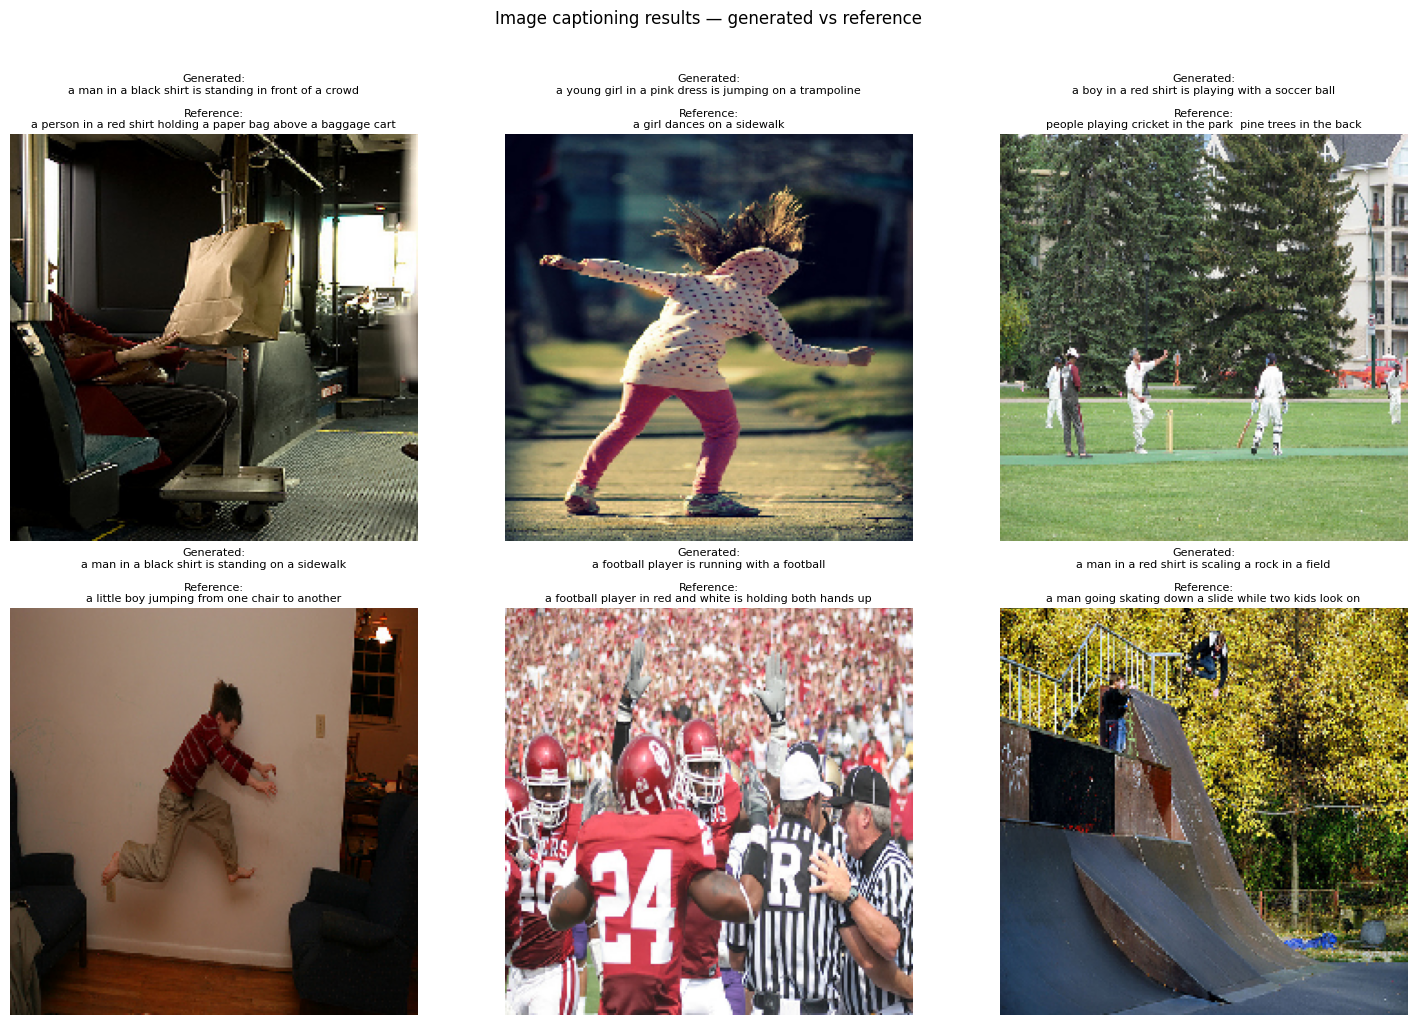

Saved!


In [38]:
def show_caption_results(image_ids, n=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, image_id in enumerate(image_ids[:n]):
        img_path = os.path.join(images_path, image_id)
        img = load_img(img_path, target_size=(224, 224))
        axes[i].imshow(img)

        generated = generate_caption(model, tokenizer, features,
                                     image_id, max_caption_length)
        best_ref = captions[image_id][0].replace(
            'startseq ', '').replace(' endseq', '')

        axes[i].set_title(
            f"Generated:\n{generated}\n\nReference:\n{best_ref}",
            fontsize=8, pad=4
        )
        axes[i].axis('off')

    plt.suptitle('Image captioning results — generated vs reference',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('/kaggle/working/caption_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved!")

show_caption_results(test_ids[:6])

# Saving everything

In [39]:
model.save('/kaggle/working/caption_model.keras')

with open('/kaggle/working/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('/kaggle/working/image_features.pkl', 'wb') as f:
    pickle.dump(features, f)

config = {
    'max_caption_length': max_caption_length,
    'vocab_size': vocab_size,
    'feature_size': 2048
}

import json
with open('/kaggle/working/model_config.json', 'w') as f:
    json.dump(config, f)

print("All artifacts saved!")
print(f"Model size: {os.path.getsize('/kaggle/working/caption_model.keras')/(1024*1024):.2f} MB")

All artifacts saved!
Model size: 64.37 MB
